# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Isabella Mazzei
* Username: ibmazzei
* Student number: s6253636
* Group (AS1, etc.): AS3

-----

In [1]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

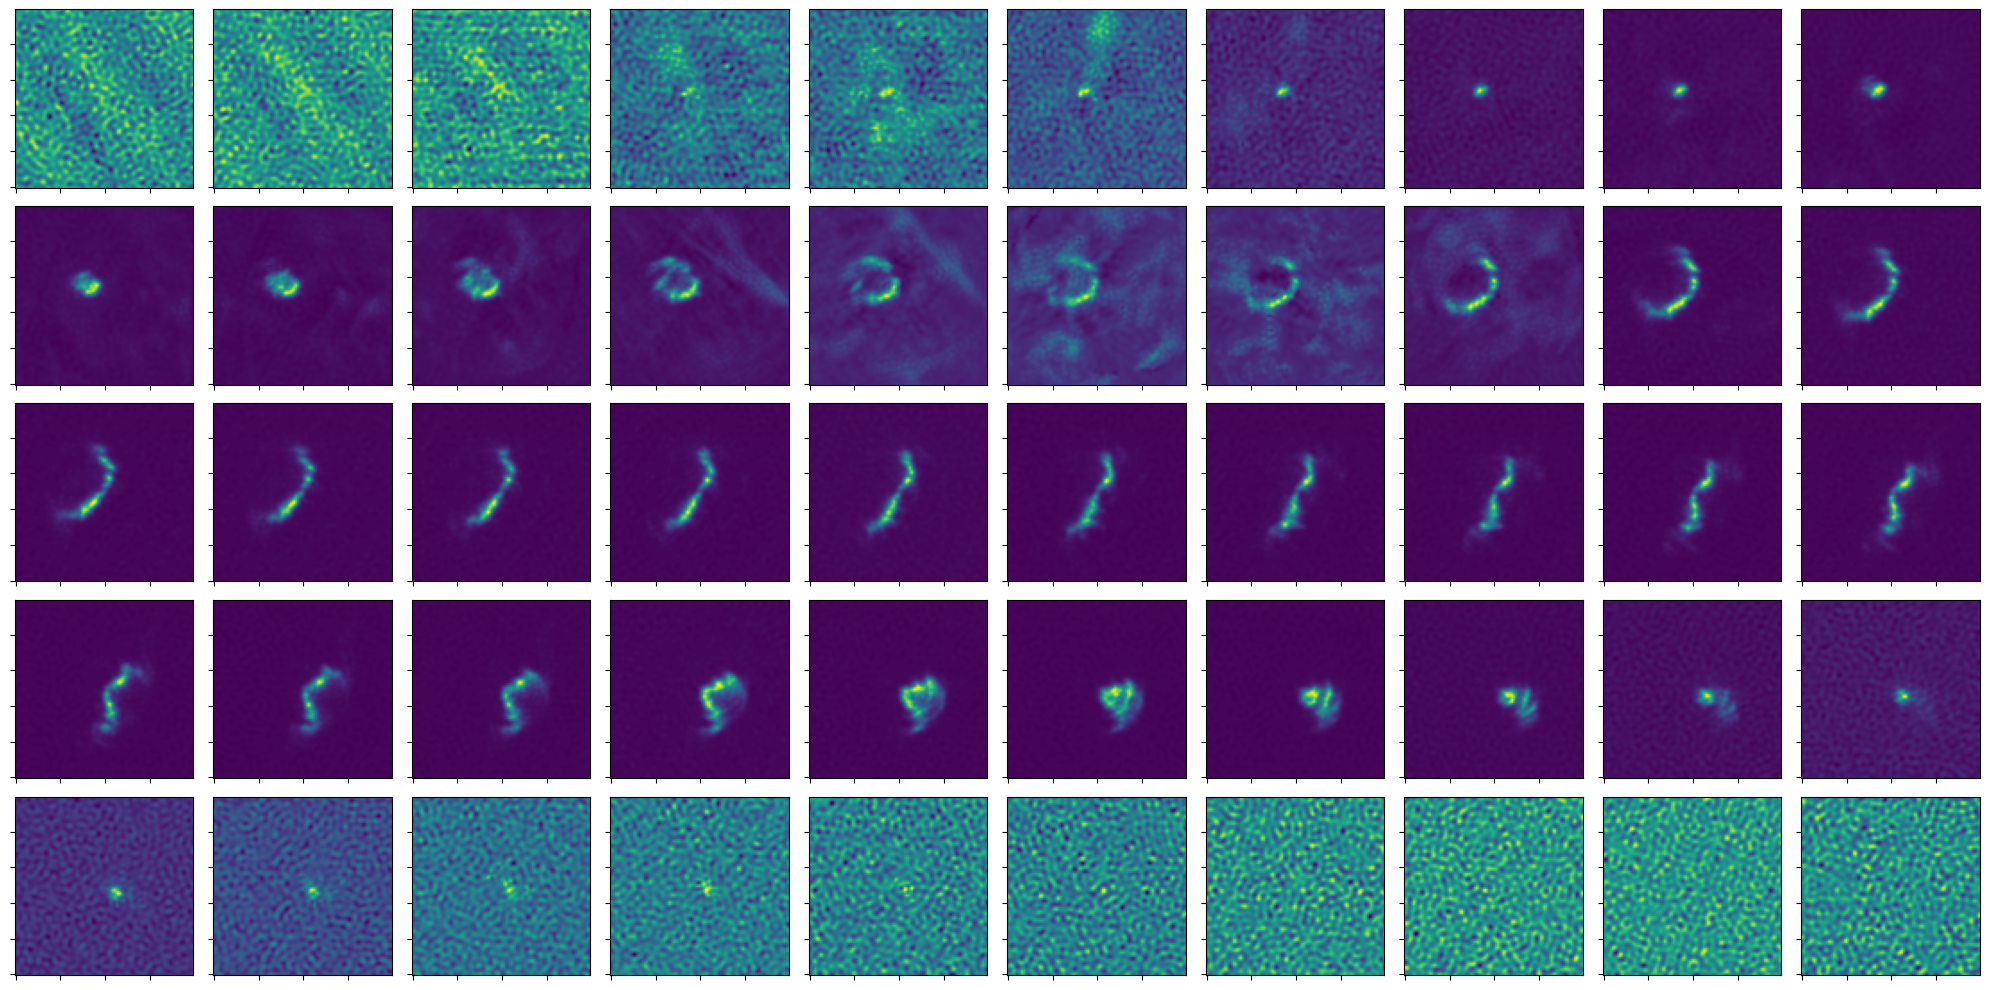

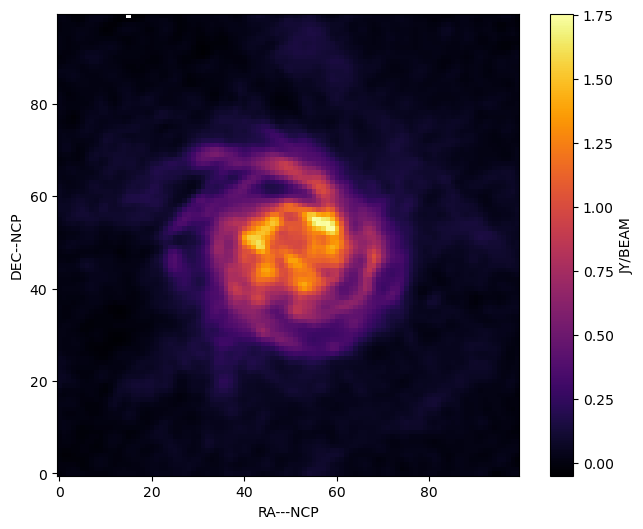

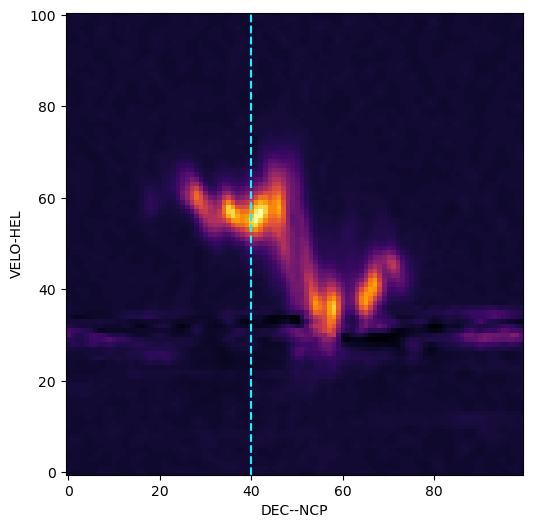

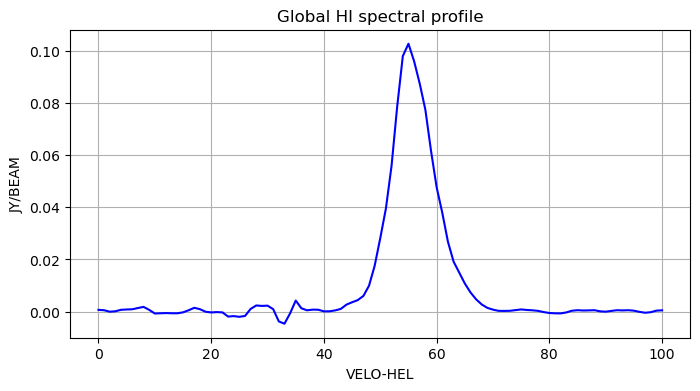

In [2]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Load FITS file
hdul = fits.open("ngc6946.fits")
data = hdul[0].data      
header = hdul[0].header

# Take the range of z
z_indices = range(1, 101, 2) 
nrows, ncols = 5, 10
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10))

# Making the plots

for i, z in enumerate(z_indices):
    # Determine the row and column for this subplot
    row = i // ncols    # Integer division to get the row index
    col = i % ncols     # Modulus to get the column index
    frame = axes[row, col]
    image = frame.imshow(data[z], origin='lower', cmap='viridis')
    frame.set_xticklabels([])
    frame.set_yticklabels([])

plt.tight_layout()
plt.show()

# Making the total HI plot

total_hi = np.sum(data[14:80], axis=0)

fig2, frame2 = plt.subplots(figsize=(8, 6))
im = frame2.imshow(total_hi, origin='lower', cmap='inferno')

# Label axes
frame2.set_xlabel(header['CTYPE1'])
frame2.set_ylabel(header['CTYPE2'])

# Add a normal colorbar
cbar = plt.colorbar(im)  
cbar.set_label(header['BUNIT'])

plt.show()

# PV Map

RA_index = 50
DE_index = 40

PVmap = data[:,:,RA_index]

fig3, frame3 = plt.subplots(figsize=(8, 6))
im = frame3.imshow(PVmap, origin='lower', cmap='inferno')

# Plot a vertical line at Dec. with index 40
frame3.axvline(DE_index, color='cyan', linestyle='--')
frame3.set_xlabel(header['CTYPE2'])
frame3.set_ylabel(header['CTYPE3'])
plt.show()

# A global HI spectral profile

global_profile = data[:, DE_index, RA_index]  # along spectral axis

plt.figure(figsize=(8, 4))
plt.plot(global_profile, color='blue')
plt.xlabel(header['CTYPE3'])
plt.ylabel(header['BUNIT'])
plt.title('Global HI spectral profile')
plt.grid(True)
plt.show()

In [3]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

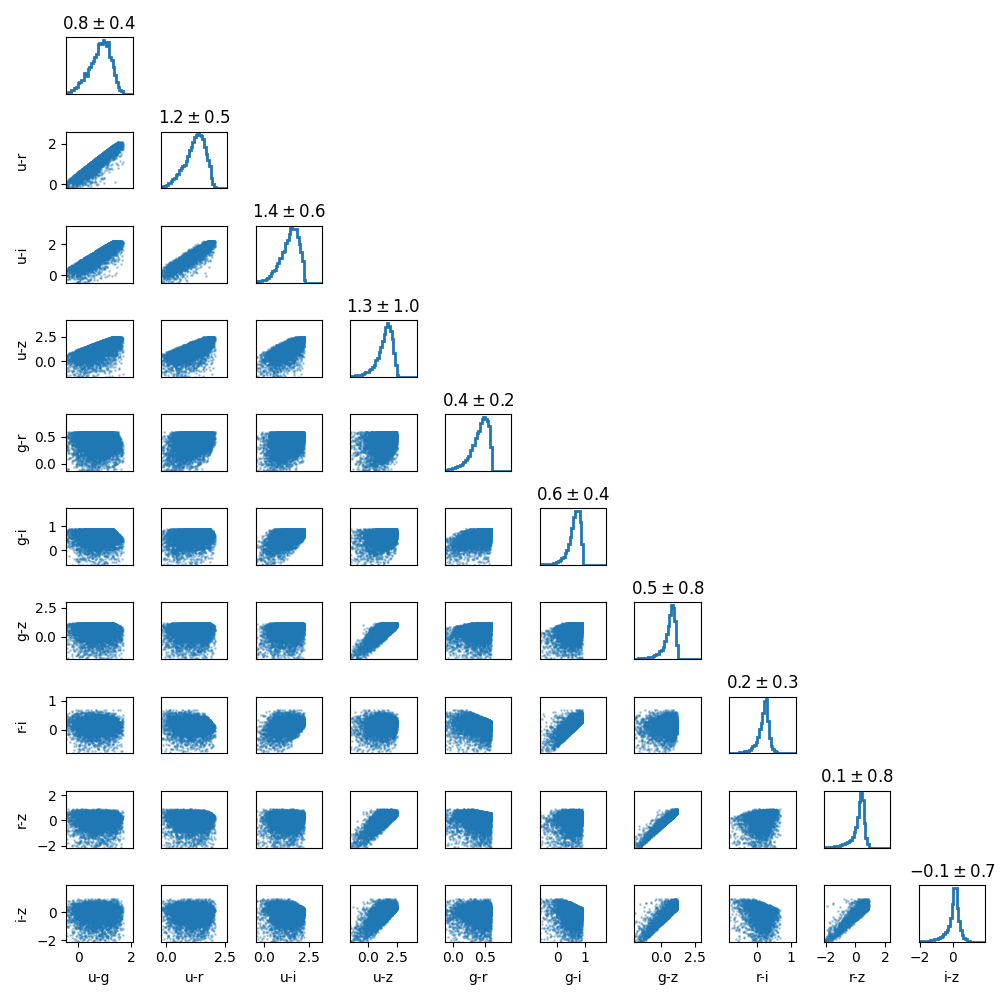
   
**Plot and answer**:

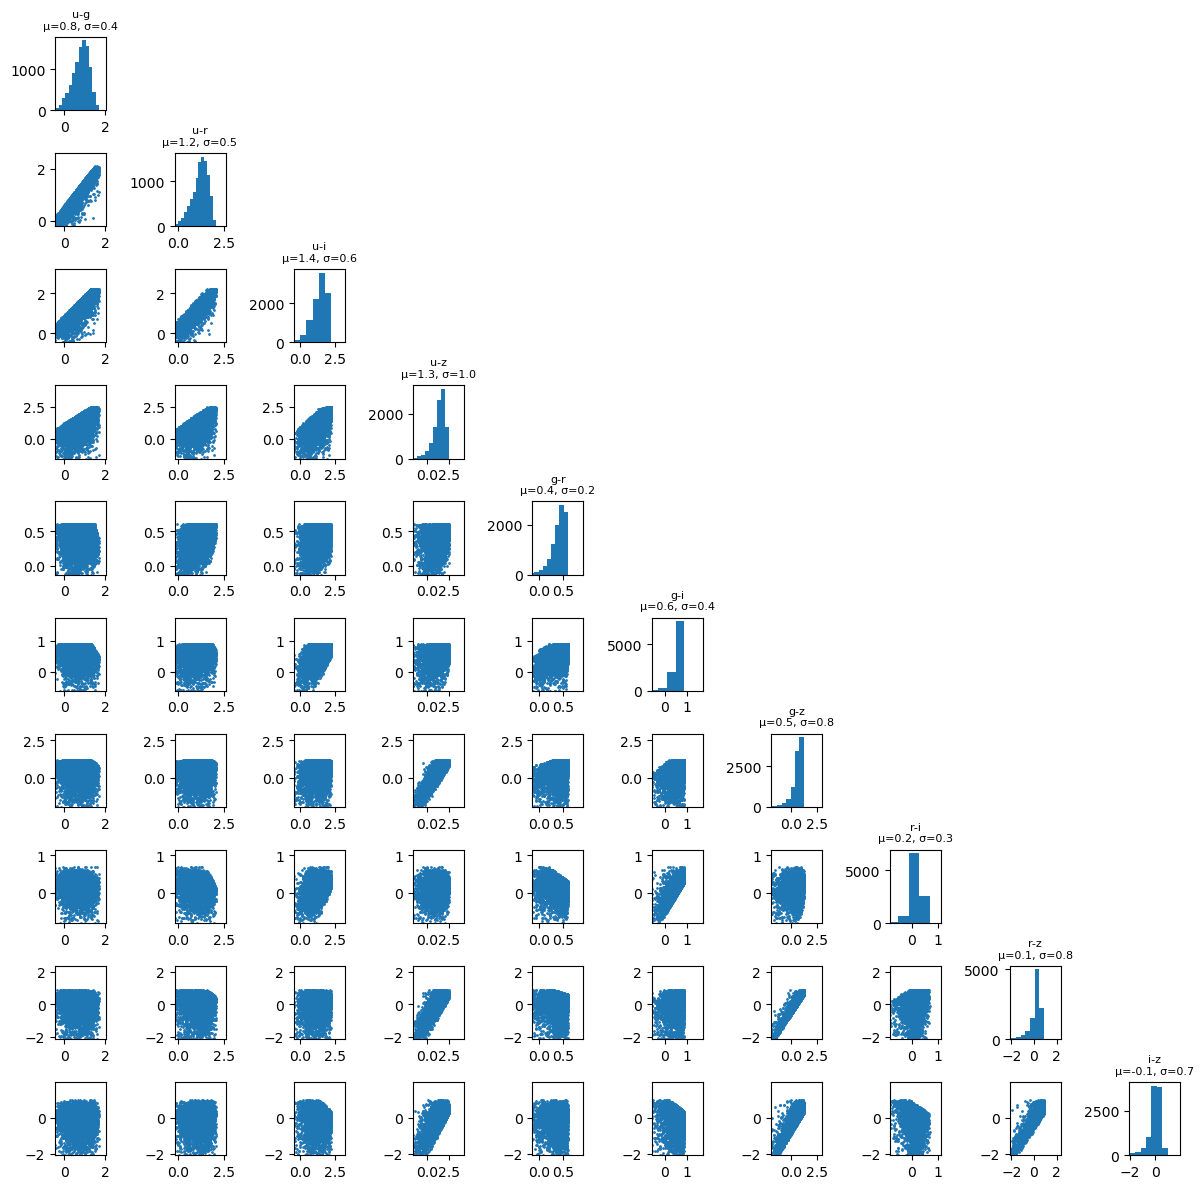

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import itertools
from astropy.table import Table

# Load  file
hdul = fits.open("SDSS_DR17_galaxies.fits")
data = hdul[1].data   # the table is usually stored in extension 1

# Convert fits table to Pandas DataFrame (easier to work with)
table = Table(data)
df = table.to_pandas()

# Select only the magnitude columns (u, g, r, i, z filters)
filters = ['u', 'g', 'r', 'i', 'z']
df = df[filters]

# Remove rows with negative values (invalid magnitudes)
df = df[(df >= 0).all(axis=1)]

# Compute colours (difference between magnitudes)
colour_dict = {}

# Loop over all pairs of filters (u-g, u-r, etc.)
for f1, f2 in itertools.combinations(filters, 2):
    name = f"{f1}-{f2}"              # name of the colour
    colour_dict[name] = df[f1] - df[f2]  # compute colour

# Convert colours into a new DataFrame
colours_df = pd.DataFrame(colour_dict)

# Compute mean and standard deviation for each colour
means = colours_df.mean()
stds = colours_df.std()

# Create corner plot (matrix of plots)
n = len(colours_df.columns)
fig, axes = plt.subplots(n, n, figsize=(12, 12))

# Loop over rows and columns of the plot grid
for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        # Select data for plotting
        x = colours_df.iloc[:, j]
        y = colours_df.iloc[:, i]

        # Diagonal: histogram of each colour
        if i == j:
            ax.hist(x, bins=30)

            mean = means.iloc[j]
            std = stds.iloc[j]

            # Title shows colour name + mean and std (1 decimal)
            ax.set_title(f"{colours_df.columns[j]}\nμ={mean:.1f}, σ={std:.1f}", fontsize=8)

            # Limit x-axis to ±3 standard deviations
            ax.set_xlim(mean - 3*std, mean + 3*std)

        # Lower triangle: scatter plots between two colours
        elif i > j:
            ax.scatter(x, y, s=1)

            mean_x = means.iloc[j]
            std_x = stds.iloc[j]
            mean_y = means.iloc[i]
            std_y = stds.iloc[i]

            # Limit both axes to ±3 standard deviations
            ax.set_xlim(mean_x - 3*std_x, mean_x + 3*std_x)
            ax.set_ylim(mean_y - 3*std_y, mean_y + 3*std_y)

        # Upper triangle: left empty for cleaner visualization
        else:
            ax.axis('off')

# Adjust spacing so plots don’t overlap
plt.tight_layout()
plt.show()

In [5]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

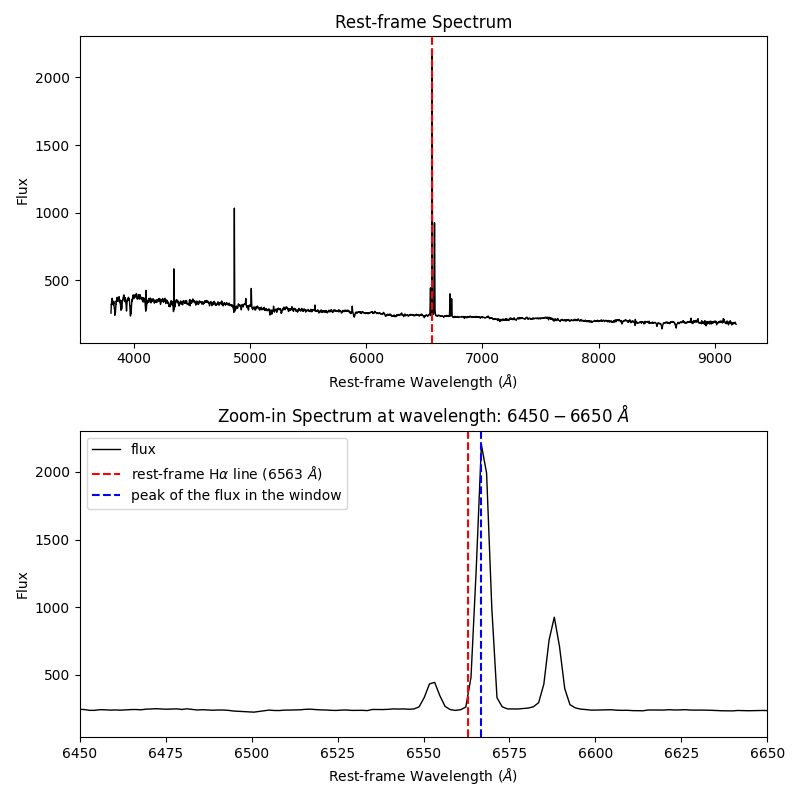

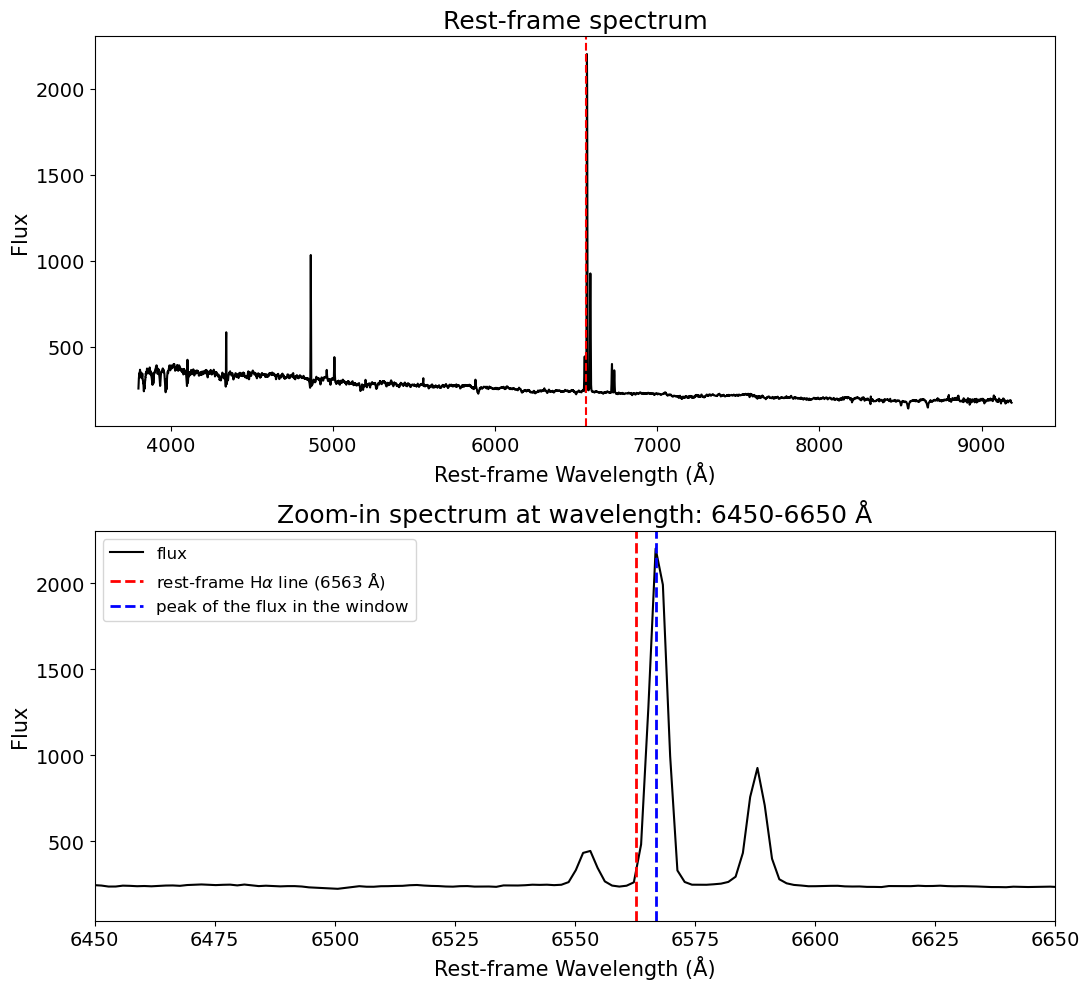

Velocity: 182.05 km/s


In [6]:
from astropy import coordinates as coords
from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
import numpy as np

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

xid = SDSS.query_region(pos, radius='10 arcsec', spectro=True)

sp = SDSS.get_spectra(matches=xid)

hdul = sp[0]

dat = hdul[1].data
flux = dat["flux"]
wavelength_log = dat["loglam"]
wavelength_obs = 10**wavelength_log
z = 0.0038
rest_wavelength = wavelength_obs/(1+z)

halpha_rest = 6562.8

zoom_min = 6450
zoom_max = 6650

peakflux = flux.max()

zoom_mask = (rest_wavelength >= zoom_min) & (rest_wavelength <= zoom_max)

wave_zoom = rest_wavelength[zoom_mask]
flux_zoom = flux[zoom_mask]

# Index of max flux
idx = np.argmax(flux[zoom_mask])

# Wavelength with it
peak_wave_rest = rest_wavelength[zoom_mask][idx]
peak_flux = flux[zoom_mask][idx]

# Object-oriented plotting

fig, (frame1, frame2) = plt.subplots(2, 1, figsize=(11, 10), sharex=False)

# Top plot

frame1.plot(rest_wavelength, flux, lw=1.5, color='black', label="Rest-frame spectrum")
frame1.axvline(halpha_rest, ls="--", lw=1.5, color='red', label=r"rest-frame H$\alpha$ line (6563 Å)")

frame1.set_title("Rest-frame spectrum", fontsize=18)
frame1.set_xlabel("Rest-frame Wavelength (Å)", fontsize=15)
frame1.set_ylabel("Flux", fontsize=15)



# Bottom plot
frame2.plot(rest_wavelength, flux, lw=1.5 ,color='black', label="flux")
frame2.set_xlim(6450, 6650)

# Expected observed H-alpha from z
halpha_obs_expected = halpha_rest * (1 + z)

frame2.axvline(halpha_rest, ls="--", lw=2, color='red', label=r"rest-frame H$\alpha$ line (6563 Å)")
frame2.axvline(peak_wave_rest, ls="--", lw=2, color='blue', label="peak of the flux in the window")

frame2.set_title("Zoom-in spectrum at wavelength: 6450-6650 Å", fontsize=18)
frame2.set_xlabel("Rest-frame Wavelength (Å)", fontsize=15)
frame2.set_ylabel("Flux", fontsize=15)
frame2.legend(loc='upper left', fontsize=12)

frame1.tick_params(axis='both', labelsize=14)  
frame2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

# Calculating velocity

delta_lambda = peak_wave_rest - halpha_rest
c_kms = 299792.458  # km/s

velocity_kms = c_kms * (delta_lambda / halpha_rest)

print(f"Velocity: {velocity_kms:.2f} km/s")

In [7]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

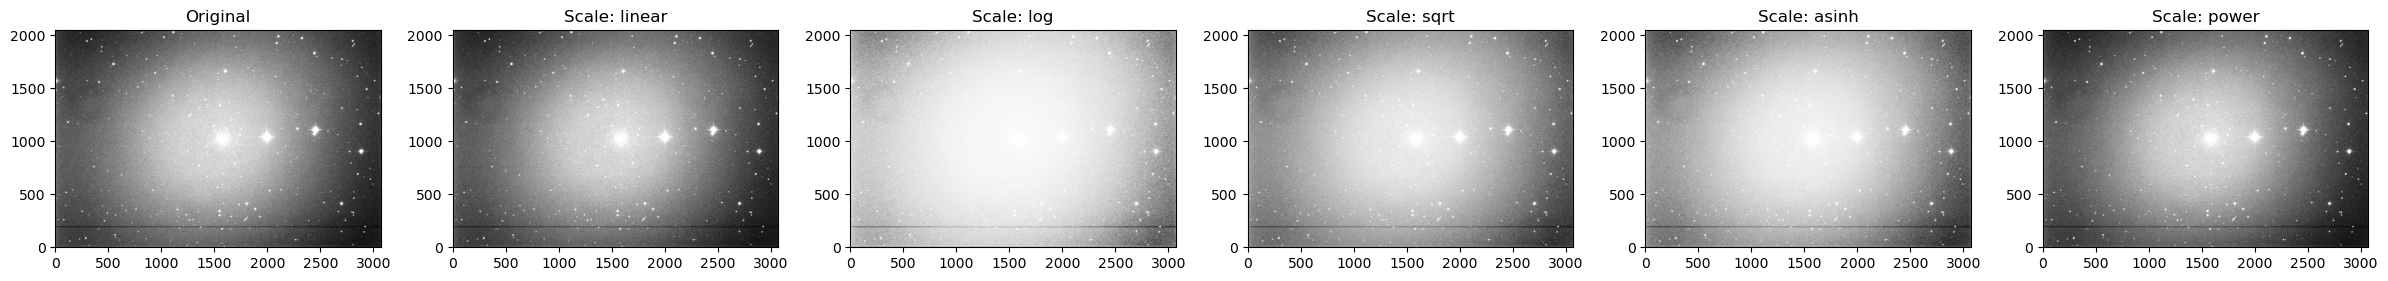

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

#define im display
def imdisplay(image, ax=None, scale='linear', cmap='gray', percentlow=5, percenthigh=95):
    """
    Display a 2D FITS image with optional scaling/stretch.
    """
    if ax is None:
        fig, ax = plt.subplots()
    norm = simple_norm(image, stretch=scale, min_percent=percentlow, max_percent=percenthigh)
    ax.imshow(image, origin='lower', cmap=cmap, norm=norm)
    return ax

# Open the FITS file
filename = "20210422_Li_.00000066.FIT"
hdul = fits.open(filename)
image_data = hdul[0].data 

# Define the function to make a mosaic
def plot_fits_mosaic(image):
    """
    Plots a mosaic of a FITS image using different stretches/scales.
    
    Parameters:
    -----------
    image : 2D numpy array
        The image data to be displayed.
    
    The function will show:
    - The original image without scaling
    - Images using all available scales in imdisplay()
    """
    scales = ['linear', 'log', 'sqrt', 'asinh', 'power']  
    
    # Number of plots: 1 for original + all scales
    n_plots = 1 + len(scales)
    
    # Create a figure with subplots
    fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 4))
    
    # Plot the original image (no scaling)
    imdisplay(image, scale='linear', ax=axes[0])  # ax= to plot in the correct subplot
    axes[0].set_title("Original", fontsize=12)
    
    # Plot images with different scales
    for i, scale in enumerate(scales):
        imdisplay(image, scale=scale, ax=axes[i+1])
        axes[i+1].set_title(f"Scale: {scale}", fontsize=12)
    
    # Adjust spacing to avoid overlapping titles
    plt.tight_layout()
    plt.show()

# Call the function with the image data
plot_fits_mosaic(image_data)

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import astroalign as aa

# imdisplay function from your notebook
from astropy.visualization import simple_norm

def imdisplay(image, ax=None, scale='linear', cmap='gray'):
    """Display a 2D image with optional scaling."""
    if ax is None:
        fig, ax = plt.subplots()
    norm = simple_norm(image, stretch=scale)
    ax.imshow(image, origin='lower', cmap=cmap, norm=norm)
    return ax

# 1. Load all FITS images
folder = "/net/dataserver3/data/users/sterrenwacht/images/220502/STL-6303E/i"

# List of FITS filenames to use
file_list = [
    "220502_Li_.00000037.Mosaic__A53.FIT",
    "220502_Li_.00000032.Mosaic__A52.FIT",
    "220502_Li_.00000047.Mosaic__A63.DARK.FIT"
    "220502_Li_.00000052.Mosaic__A63.BIAS.FIT"
]

# Read the images into a list
images = []
for fname in file_list:
    hdul = fits.open(folder + fname)
    images.append(hdul[0].data.astype(float))  # convert to float
    hdul.close()


# 2. Stack the images (without alignment)
datacube = np.stack(images)             # combine all images into a 3D array
stacked_image = np.median(datacube, 0)  # take median along the stack

# Display the stacked image
fig, ax = plt.subplots(figsize=(6,6))
imdisplay(stacked_image, ax, scale='linear')
ax.set_title("Stacked Image (no alignment)")
plt.show()


# 3. Align images and stack again
# Choose the first image as the target
target_image = images[0]

aligned_images = []
for i, img in enumerate(images):
    if i == 0:
        aligned_images.append(target_image)  # first image is already aligned
    else:
        aligned_img, footprint = aa.register(img, target_image)
        aligned_images.append(aligned_img)

# Stack the aligned images
datacube_aligned = np.stack(aligned_images)
stacked_aligned = np.median(datacube_aligned, 0)

# Display the aligned stacked image
fig, ax = plt.subplots(figsize=(6,6))
imdisplay(stacked_aligned, ax, scale='linear')
ax.set_title("Stacked Image (aligned)")
plt.show()

ModuleNotFoundError: No module named 'astroalign'

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")